In [1]:
import cv2
import numpy as np

# Load the image
image = cv2.imread("Train_Data_Phase1/Beauty_prescription_2.jpg", cv2.IMREAD_GRAYSCALE)

# Apply adaptive thresholding
thresh = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, 11, 2)

# Find contours (potential handwritten text regions)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours based on aspect ratio and size (handwritten text tends to be smaller, irregular)
handwritten_regions = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if 20 < w < 500 and 10 < h < 100:  # Filter sizes based on observed handwriting
        handwritten_regions.append((x, y, w, h))

# Draw bounding boxes around detected handwritten text
handwritten_only = np.zeros_like(image)
for (x, y, w, h) in handwritten_regions:
    handwritten_only[y:y+h, x:x+w] = image[y:y+h, x:x+w]

cv2.imwrite("handwritten_extracted.jpg", handwritten_only)


True

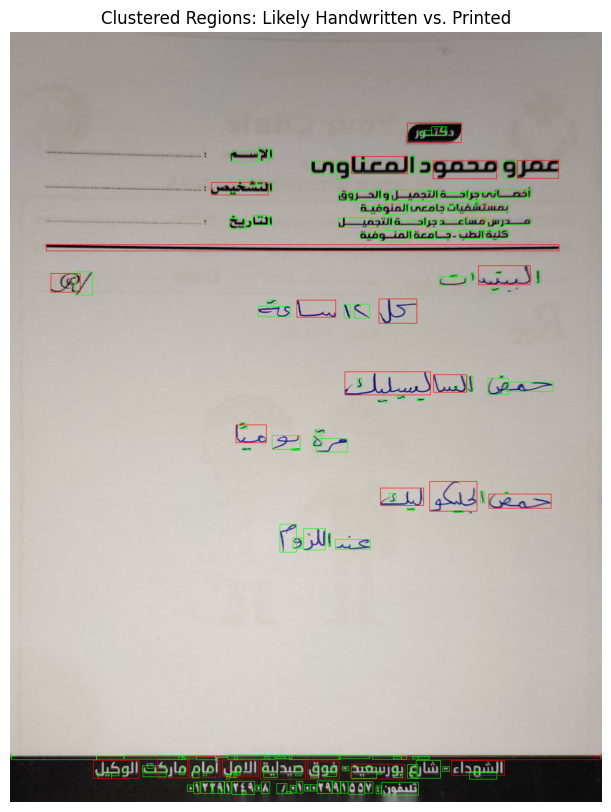

In [3]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def preprocess_image(image_path):
    # Load image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply Gaussian blur to remove noise
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    
    # Apply adaptive thresholding to create a binary image
    binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 2)
    return binary

def extract_connected_components(binary):
    # Find contours as candidate regions
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    regions = []
    features = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        # Basic filtering by size
        if w*h > 200:  # minimal area filter
            region = binary[y:y+h, x:x+w]
            regions.append((x, y, w, h))
            
            # Compute features: aspect ratio, area, and mean intensity (as a proxy for stroke density)
            aspect_ratio = float(w) / h
            area = w * h
            mean_intensity = np.mean(region)
            features.append([aspect_ratio, area, mean_intensity])
    return regions, np.array(features)

def cluster_regions(features, n_clusters=2):
    # Use KMeans clustering to separate regions
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(features)
    return clusters

def draw_clusters(image_path, regions, clusters):
    image = cv2.imread(image_path)
    colors = [(0,255,0), (0,0,255)]
    for i, (x, y, w, h) in enumerate(regions):
        cv2.rectangle(image, (x, y), (x+w, y+h), colors[clusters[i] % len(colors)], 2)
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Clustered Regions: Likely Handwritten vs. Printed")
    plt.axis("off")
    plt.show()

# Main processing
image_path = "Train_Data_Phase1/Beauty_prescription_2.jpg"  # Replace with your image path
binary_image = preprocess_image(image_path)
regions, features = extract_connected_components(binary_image)
clusters = cluster_regions(features, n_clusters=2)
draw_clusters(image_path, regions, clusters)


In [5]:
pip install torchvision

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 1.3 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.6 MB 1.4 MB/s eta 0:00:01
   -------------------------- ------------- 1.0/1.6 MB 1.3 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/204.1 MB ? eta -:--:

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Python312\\share'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import segmentation_models_pytorch as smp  # requires pip install segmentation-models-pytorch

# Suppose we load a pretrained U-Net model (for demonstration, we use a model pretrained on ImageNet)
# Note: You might want to use a model fine-tuned on document segmentation if available.
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
model.eval()  # Set model to evaluation mode

# Define transformation
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  std=[0.229, 0.224, 0.225]),
])

def segment_handwritten_region(image_path, model, transform):
    # Load and transform the image
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0)  # add batch dimension
    
    with torch.no_grad():
        # Get segmentation mask; assume output is a single channel probability map
        output = model(input_tensor)
        mask = torch.sigmoid(output).squeeze().cpu().numpy()
        
    # Threshold mask to obtain binary segmentation
    binary_mask = (mask > 0.5).astype(np.uint8) * 255
    return image, binary_mask

# Run segmentation
image_path = "Train_Data_Phase1/Beauty_prescription_2.jpg"  # Replace with your image path
orig_image, handwritten_mask = segment_handwritten_region(image_path, model, transform)

# Visualize result
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(orig_image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(handwritten_mask, cmap="gray")
plt.title("Extracted Handwritten Regions (Mask)")
plt.axis("off")
plt.show()


ModuleNotFoundError: No module named 'torchvision'

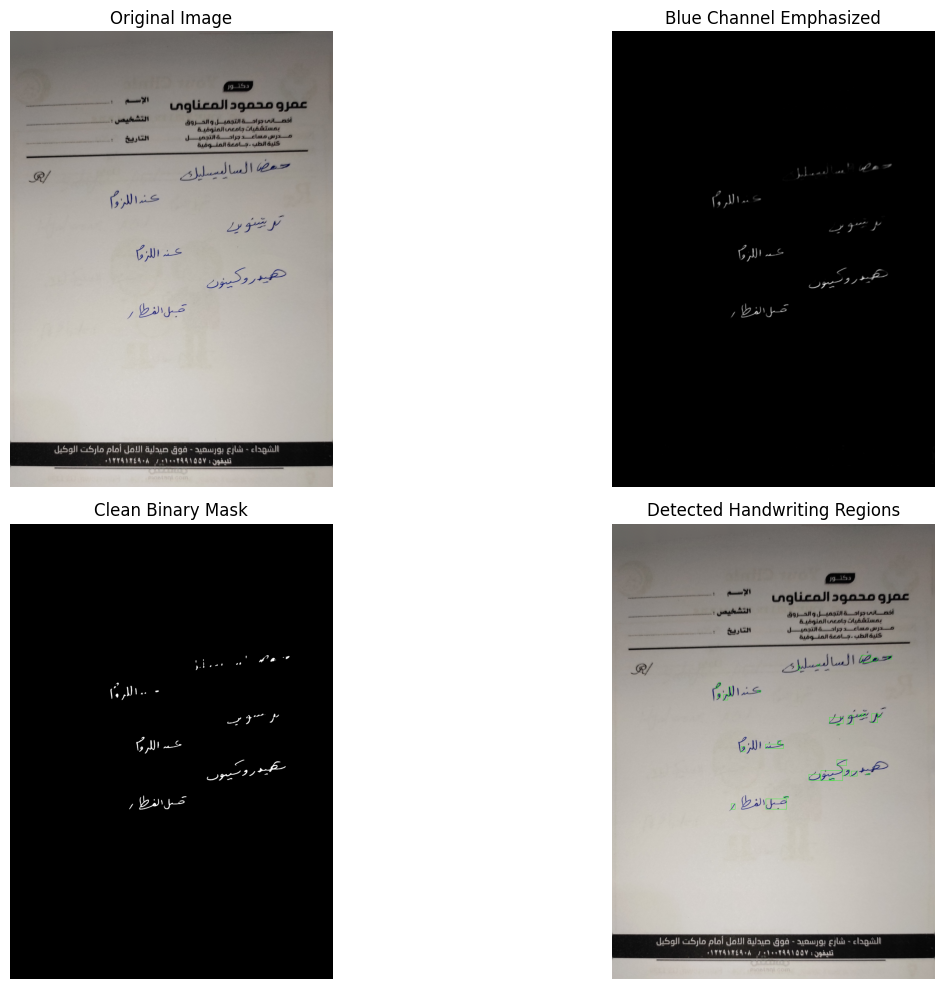

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image
image = cv2.imread("Train_Data_Phase1/Beauty_prescription_148.jpg")
original = image.copy()

# 2. Convert to Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Emphasize blue ink (blue channel minus red+green average)
b, g, r = cv2.split(image)
blue_emphasized = cv2.subtract(b, cv2.addWeighted(r, 0.5, g, 0.5, 0))

# Optional: Normalize or smooth
blue_emphasized = cv2.GaussianBlur(blue_emphasized, (3, 3), 0)

# 4. Threshold to isolate blue ink
_, binary = cv2.threshold(blue_emphasized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5. Morphological operations to remove noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 6. Find contours to get bounding boxes of handwritten regions
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 7. Draw or extract bounding boxes (optional)
result_img = original.copy()
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if 20 < w < 300 and 10 < h < 100:  # Filter out noise and large blocks
        cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

# 8. Plot results using matplotlib
plt.figure(figsize=(15, 10))

# Original Image
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Blue Emphasized
plt.subplot(2, 2, 2)
plt.imshow(blue_emphasized, cmap='gray')
plt.title('Blue Channel Emphasized')
plt.axis('off')

# Clean Mask
plt.subplot(2, 2, 3)
plt.imshow(clean, cmap='gray')
plt.title('Clean Binary Mask')
plt.axis('off')

# Result with Bounding Boxes
plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title('Detected Handwriting Regions')
plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image
image = cv2.imread("Train_Data_Phase1/Beauty_prescription_148.jpg")
original = image.copy()

# 2. Split into BGR channels
b, g, r = cv2.split(image)

# 3. Enhance Blue Channel (Increase Contrast & Brightness)
# Method 1: Linear Scaling (Brightness & Contrast)
alpha = 1.5  # Contrast control (1.0-3.0)
beta = 30    # Brightness control (0-100)
enhanced_b = cv2.convertScaleAbs(b, alpha=alpha, beta=beta)

# Method 2: Gamma Correction (Alternative Approach)
# gamma = 0.5  # Values <1 make blue brighter
# enhanced_b = np.power(b / 255.0, gamma) * 255.0
# enhanced_b = enhanced_b.astype(np.uint8)

# 4. Subtract Red & Green to Isolate Blue Ink
blue_emphasized = cv2.subtract(enhanced_b, cv2.addWeighted(r, 0.5, g, 0.5, 0))

# 5. Apply Gaussian Blur (Optional)
blue_emphasized = cv2.GaussianBlur(blue_emphasized, (3, 3), 0)

# 6. Adaptive Thresholding (Better than Otsu for varying lighting)
binary = cv2.adaptiveThreshold(
    blue_emphasized, 
    255, 
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 
    11, 
    2
)

# 7. Morphological Operations (Clean Up Noise)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 8. Find Contours & Draw Bounding Boxes
result_img = original.copy()
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if 20 < w < 300 and 10 < h < 100:
        cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

# 9. Display Results with Matplotlib
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(enhanced_b, cmap='Blues')  # Use 'Blues' colormap for better visibility
plt.title('Enhanced Blue Channel')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(clean, cmap='gray')
plt.title('Final Binary Mask')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title('Detected Handwriting')
plt.axis('off')

plt.tight_layout()
plt.show()

AttributeError: 'NoneType' object has no attribute 'copy'

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image
image = cv2.imread("prescription_opth_203.jpg")
original = image.copy()

# ===== NEW: PRE-PROCESSING =====
# 2. Normalize intensity (improves contrast)
normalized = cv2.normalize(image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

# 3. Convert to LAB color space and apply CLAHE to L-channel (for illumination correction)
lab = cv2.cvtColor(normalized, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
l_eq = clahe.apply(l)
lab_eq = cv2.merge((l_eq, a, b))
equalized = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
# ===== END PRE-PROCESSING =====

# 4. Emphasize blue ink (now using equalized image)
b, g, r = cv2.split(equalized)  # Changed from 'image' to 'equalized'
blue_emphasized = cv2.subtract(b, cv2.addWeighted(r, 0.5, g, 0.5, 0))

# 5. Apply Gaussian Blur
blue_emphasized = cv2.GaussianBlur(blue_emphasized, (3, 3), 0)

# 6. Threshold with hysteresis-like approach
_, weak = cv2.threshold(blue_emphasized, 20, 255, cv2.THRESH_BINARY)  # Lower threshold
_, strong = cv2.threshold(blue_emphasized, 80, 255, cv2.THRESH_BINARY)  # Higher threshold
binary = cv2.bitwise_or(strong, cv2.bitwise_and(weak, cv2.dilate(strong, None)))

# 7. Morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 8. Find and crop handwriting
y_coords, x_coords = np.where(clean_mask == 255)
padding = 20  # Reduced padding for tighter crop
if len(x_coords) > 0:
    x_min, x_max = np.min(x_coords), np.max(x_coords)
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    # Apply padding with boundary checks
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(image.shape[1], x_max + padding)
    y_max = min(image.shape[0], y_max + padding)
    cropped_handwritten = original[y_min:y_max, x_min:x_max]
    result_img = original.copy()
    cv2.rectangle(result_img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
else:
    cropped_handwritten = None
    result_img = original.copy()

# 9. Enhanced plotting with pre-processing steps
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(normalized, cv2.COLOR_BGR2RGB))
plt.title('Normalized Image')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(equalized, cv2.COLOR_BGR2RGB))
plt.title('Contrast Equalized')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(blue_emphasized, cmap='gray')
plt.title('Blue-Emphasized')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(binary, cmap='gray')
plt.title('Final Mask')
plt.axis('off')

plt.subplot(2, 3, 6)
if cropped_handwritten is not None:
    plt.imshow(cv2.cvtColor(cropped_handwritten, cv2.COLOR_BGR2RGB))
else:
    plt.imshow(np.zeros((10, 10, 3)))
plt.title('Cropped Handwriting')
plt.axis('off')

plt.tight_layout()
plt.show()

AttributeError: 'NoneType' object has no attribute 'copy'

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image
image = cv2.imread("prescription_opth_163.jpg")
original = image.copy()

# ===== PRE-PROCESSING =====
# 2. Normalize intensity
normalized = cv2.normalize(image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

# 3. CLAHE on L channel
lab = cv2.cvtColor(normalized, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
l_eq = clahe.apply(l)
lab_eq = cv2.merge((l_eq, a, b))
equalized = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

# 4. Emphasize blue ink
b, g, r = cv2.split(equalized)
blue_emphasized = cv2.subtract(b, cv2.addWeighted(r, 0.5, g, 0.5, 0))

# 5. Gaussian Blur
blue_emphasized = cv2.GaussianBlur(blue_emphasized, (3, 3), 0)

# 6. Adaptive thresholding based on max value
max_val = np.max(blue_emphasized)
lower_thresh = 0.35 * max_val
upper_thresh = 0.75 * max_val

_, weak = cv2.threshold(blue_emphasized, lower_thresh, 255, cv2.THRESH_BINARY)
_, strong = cv2.threshold(blue_emphasized, upper_thresh, 255, cv2.THRESH_BINARY)
binary = cv2.bitwise_or(strong, cv2.bitwise_and(weak, cv2.dilate(strong, None)))

# 7. Morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 8. Find and crop handwriting
y_coords, x_coords = np.where(clean_mask == 255)
padding = 100
if len(x_coords) > 0:
    x_min, x_max = np.min(x_coords), np.max(x_coords)
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    x_min = max(0, x_min - padding)
    y_min = max(0, y_min - padding)
    x_max = min(image.shape[1], x_max + padding)
    y_max = min(image.shape[0], y_max + padding)
    cropped_handwritten = original[y_min:y_max, x_min:x_max]
    result_img = original.copy()
    cv2.rectangle(result_img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
else:
    cropped_handwritten = None
    result_img = original.copy()

# 9. Plotting
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(normalized, cv2.COLOR_BGR2RGB))
plt.title('Normalized Image')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(equalized, cv2.COLOR_BGR2RGB))
plt.title('Contrast Equalized')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(blue_emphasized, cmap='gray')
plt.title('Blue-Emphasized')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(binary, cmap='gray')
plt.title(f'Mask (thresh = {lower_thresh:.0f}/{upper_thresh:.0f})')
plt.axis('off')

plt.subplot(2, 3, 6)
if cropped_handwritten is not None:
    plt.imshow(cv2.cvtColor(cropped_handwritten, cv2.COLOR_BGR2RGB))
else:
    plt.imshow(np.zeros((10, 10, 3)))
plt.title('Cropped Handwriting')
plt.axis('off')

plt.tight_layout()
plt.show()


AttributeError: 'NoneType' object has no attribute 'copy'

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Image D:\telemed\Machathon_Prescription_Digtalization_6.00\prescription_opth_203.jpg
image = cv2.imread("prescription_opth_163.jpg")
original = image.copy()

# 2. Emphasize blue ink (blue channel minus red+green average)
b, g, r = cv2.split(image)
blue_emphasized = cv2.subtract(b, cv2.addWeighted(r, 0.5, g, 0.5, 0))

# 3. Apply Gaussian Blur (Optional)
blue_emphasized = cv2.GaussianBlur(blue_emphasized, (3, 3), 0)

# 4. Threshold to isolate blue ink (handwritten text)
_, binary = cv2.threshold(blue_emphasized, 100, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5. Morphological operations to remove noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# 6. Find all white pixels (handwritten text)
y_coords, x_coords = np.where(clean_mask == 255)
padding = 100
if len(x_coords) > 0 and len(y_coords) > 0:  # Ensure handwriting is detected
    # 7. Get bounding box coordinates (min/max x, y)
    x_min, x_max = np.min(x_coords), np.max(x_coords)
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    x_min, x_max = max(0, x_min - padding), min(original.shape[1], x_max + padding)  # Add padding
    y_min, y_max = max(0, y_min - padding), min(original.shape[0], y_max + padding)  # Add padding
    # 8. Crop the region from the original image
    cropped_handwritten = original[y_min:y_max, x_min:x_max]
    
    # 9. Draw the bounding box on the original image (for visualization)
    result_img = original.copy()
    cv2.rectangle(result_img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
else:
    print("No handwriting detected!")
    cropped_handwritten = None
    result_img = original.copy()

# 10. Plot results
plt.figure(figsize=(15, 10))

# Original Image
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Binary Mask
plt.subplot(2, 2, 2)
plt.imshow(clean_mask, cmap='gray')
plt.title('Binary Mask (Handwriting)')
plt.axis('off')


# Original Image with Bounding Box
plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title('Detected Handwriting Region')
plt.axis('off')

# Cropped Handwritten Region
plt.subplot(2, 2, 4)
if cropped_handwritten is not None:
    plt.imshow(cv2.cvtColor(cropped_handwritten, cv2.COLOR_BGR2RGB))
else:
    plt.imshow(np.zeros((10, 10, 3), cmap='gray'))  # Placeholder if no text detected
plt.title('Cropped Handwritten Text')
plt.axis('off')

plt.tight_layout()
plt.show()

AttributeError: 'NoneType' object has no attribute 'copy'

In [ ]:
class HandwrittenExtractor:
    def __init__(self, image_path, padding=100):
        self.image_path = image_path
        self.padding = padding
        self.original = cv2.imread(image_path)
        if self.original is None:
            raise FileNotFoundError(f"Could not load image: {image_path}")
        self.processed = None
        self.mask = None
        self.cropped = None
        self.result_img = self.original.copy()
        self._process()

    def _normalize_intensity(self, image):
        return cv2.normalize(image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)


    def _emphasize_blue(self, image):
        b, g, r = cv2.split(image)
        return cv2.subtract(b, cv2.addWeighted(r, 0.5, g, 0.5, 0))

    def _should_use_adaptive_threshold(self, blue_channel, peak_threshold=10, variance_threshold=5):
        # Smooth histogram and count peaks
        hist = cv2.calcHist([blue_channel], [0], None, [256], [0, 256]).flatten()
        smoothed_hist = cv2.GaussianBlur(hist, (9, 1), 0)
        peaks = (np.diff(np.sign(np.diff(smoothed_hist))) < 0).sum()

        # Background variance
        variance = np.var(blue_channel)
        mean_val = np.mean(blue_channel)

        print(f"[DEBUG] Blue channel stats -> Peaks: {peaks}, Mean: {mean_val:.2f}, Variance: {variance:.2f}")

        return peaks > peak_threshold or variance > variance_threshold

    def _adaptive_threshold(self, image):
        if self._should_use_adaptive_threshold(image):
            max_val = np.max(image)
            lower_thresh = 0.3 * max_val
            upper_thresh = 0.8 * max_val
            _, weak = cv2.threshold(image, lower_thresh, 255, cv2.THRESH_BINARY)
            _, strong = cv2.threshold(image, upper_thresh, 255, cv2.THRESH_BINARY)
            binary = cv2.bitwise_or(strong, cv2.bitwise_and(weak, cv2.dilate(strong, None)))
            print("[INFO] Adaptive thresholding applied.")
            return binary, lower_thresh, upper_thresh
        else:
            _, binary = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)

            print("[INFO] Adaptive thresholding not needed.")
            return binary, 10, None  # Return unchanged if not applied
        
    def _morphological_cleaning(self, binary_mask):
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
        return cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)

    def _crop_handwriting(self, mask):
        y_coords, x_coords = np.where(mask == 255)
        if len(x_coords) > 0:
            x_min, x_max = np.min(x_coords), np.max(x_coords)
            y_min, y_max = np.min(y_coords), np.max(y_coords)
            print(f"[DEBUG] Handwriting bounding box -> x:({x_min}, {x_max}), y:({y_min}, {y_max})")
            x_min = max(0, x_min - self.padding)
            y_min = max(0, y_min - self.padding)
            x_max = min(self.original.shape[1], x_max + self.padding)
            y_max = min(self.original.shape[0], y_max + self.padding)
            self.cropped = self.original[y_min:y_max, x_min:x_max]
            print(f"[DEBUG] Cropped handwriting region shape: {self.cropped.shape}")
            cv2.rectangle(self.result_img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

    def _process(self):
        norm = self._normalize_intensity(self.original)
        blue = self._emphasize_blue(norm)
        blue_emphasized = cv2.GaussianBlur(blue, (5, 5), 0)
        mask, low_t, high_t = self._adaptive_threshold(blue_emphasized)
        clean = self._morphological_cleaning(mask)
        self.mask = clean
        self._crop_handwriting(self.mask)
        self.processed = {
            "normalized": norm,
            "blue_emphasized": blue,
            "binary_mask": mask,
            "clean_mask": clean,
            "lower_thresh": low_t,
            "upper_thresh": high_t
        }

    def show_debug_plot(self):
        p = self.processed
        plt.figure(figsize=(18, 12))

        plt.subplot(2, 3, 1)
        plt.imshow(cv2.cvtColor(self.original, cv2.COLOR_BGR2RGB))
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(2, 3, 2)
        plt.imshow(cv2.cvtColor(p["normalized"], cv2.COLOR_BGR2RGB))
        plt.title('Normalized Image')
        plt.axis('off')

        plt.subplot(2, 3, 3)
        plt.imshow(p["binary_mask"], cmap='gray')
        plt.title(f'Mask ')
        plt.axis('off')



        plt.subplot(2, 3, 4)
        plt.imshow(p["blue_emphasized"], cmap='gray')
        plt.title('Blue-Emphasized')
        plt.axis('off')

        plt.subplot(2, 3, 5)
        plt.imshow(p["clean_mask"], cmap='gray')
        plt.title(f'Mask ')
        plt.axis('off')

        plt.subplot(2, 3, 6)
        if self.cropped is not None:
            plt.imshow(cv2.cvtColor(self.cropped, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(np.zeros((10, 10, 3)))
        plt.title('Cropped Handwriting')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

    def get_cropped_image(self):
        return self.cropped

    def get_clean_mask(self):
        return self.mask

    def get_visualized_result(self):
        return self.result_img


<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29348\1631380752.py:3: SyntaxWarning: invalid escape sequence '\M'
  extracted_handwriting = HandwrittenExtractor("D:\\telemed\Machathon_Prescription_Digtalization_6.00\Machathon_Prescription_Digtalization_6.00\Test_Data_Phase2\Dental_prescription_647.jpg")


[DEBUG] Blue channel stats -> Peaks: 0, Mean: 11.51, Variance: 14.50
[INFO] Adaptive thresholding applied.
[DEBUG] Handwriting bounding box -> x:(333, 1074), y:(1042, 1539)
[DEBUG] Cropped handwriting region shape: (697, 941, 3)


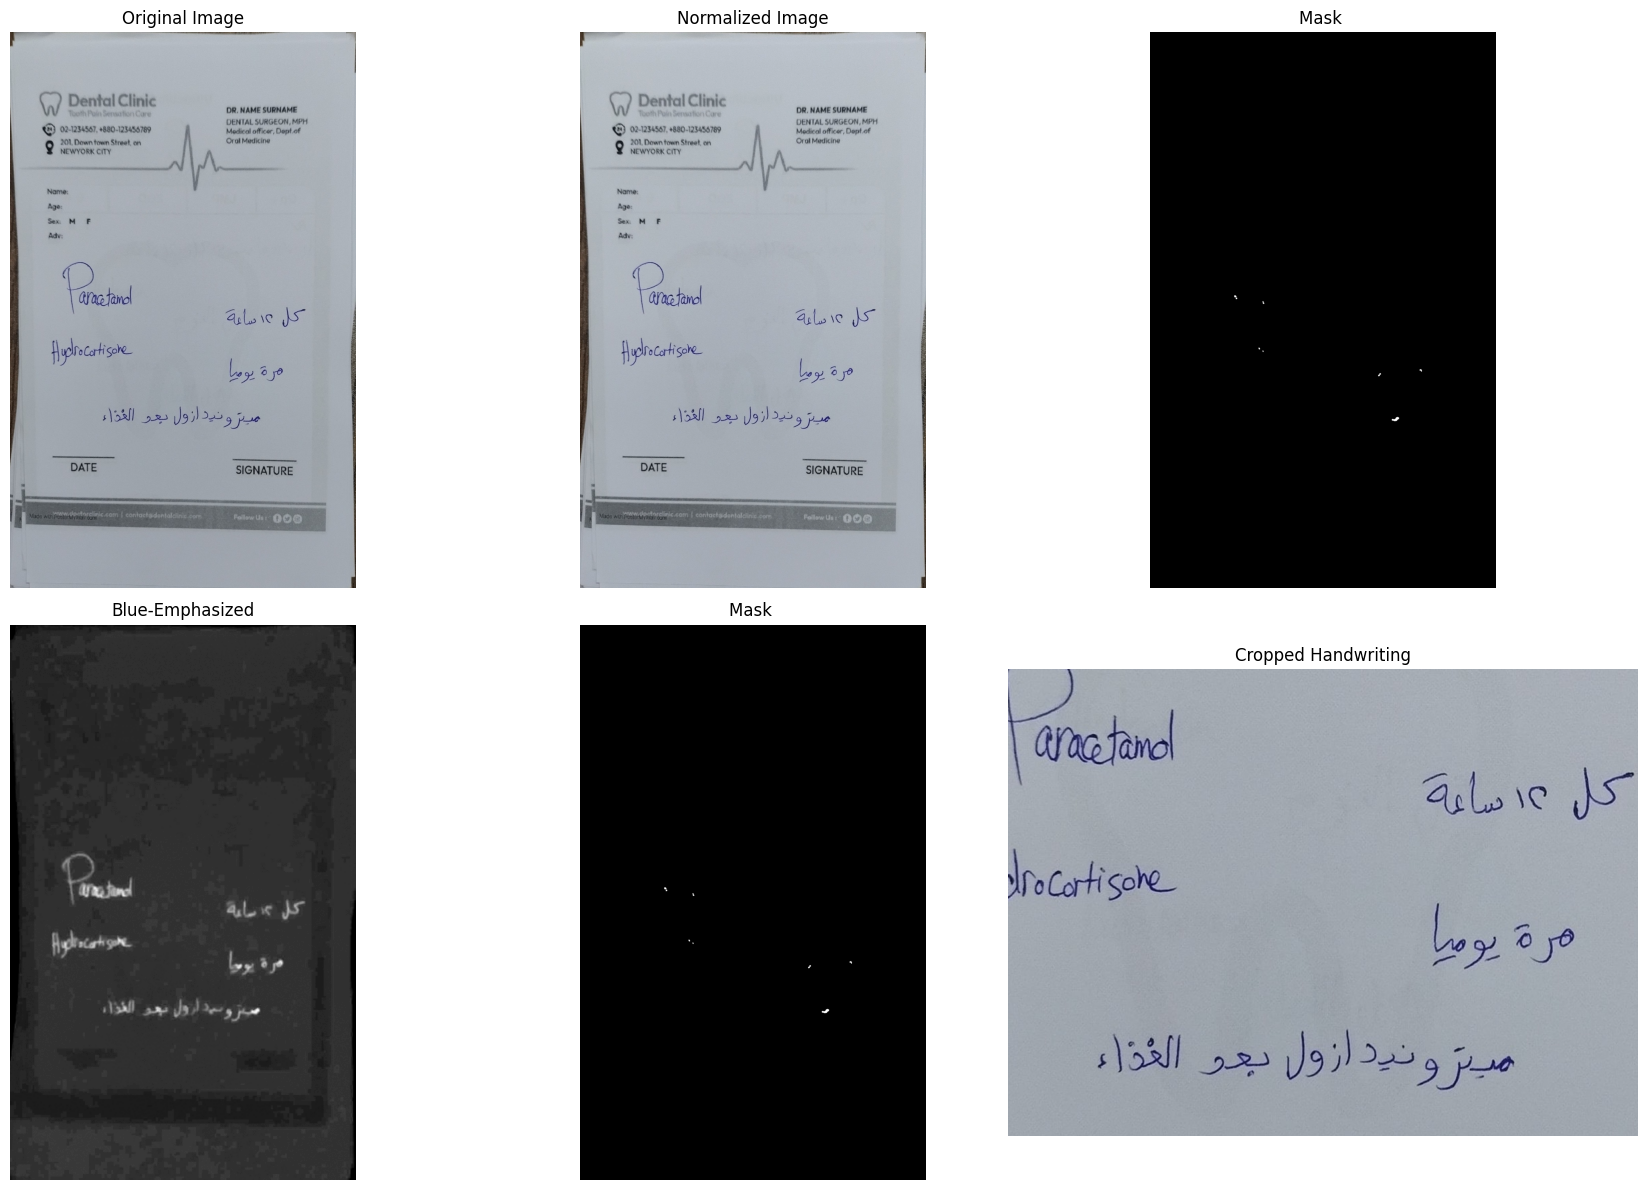

In [36]:
# D:\telemed\Machathon_Prescription_Digtalization_6.00\Machathon_Prescription_Digtalization_6.00\Test_Data_Phase2\Dental_prescription_647.jpg
import cv2
extracted_handwriting = HandwrittenExtractor("D:\\telemed\Machathon_Prescription_Digtalization_6.00\Machathon_Prescription_Digtalization_6.00\Test_Data_Phase2\Dental_prescription_647.jpg")
extracted_handwriting.show_debug_plot()

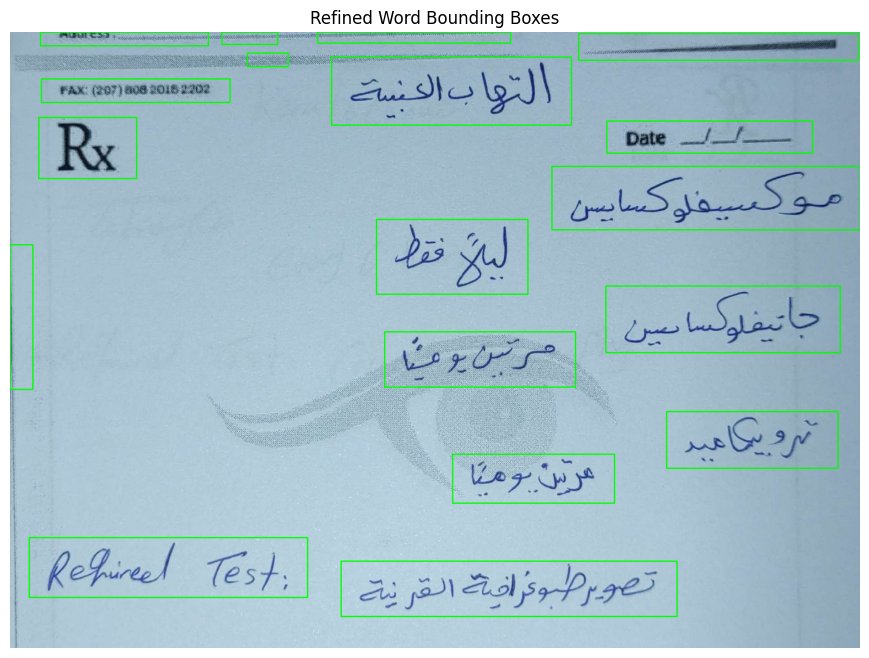

In [98]:
# Load the new image with better contours
img = extracted_handwriting.cropped
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Binary inverse threshold
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remove small noise using opening
kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_open, iterations=1)

# Dilate to group characters into words
kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 10))  # Smaller than before for finer separation
dilated = cv2.dilate(opened, kernel_dilate, iterations=3)

# Find contours
contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter overlapping and very small boxes
bounding_boxes = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > 300]

# Remove overlapping boxes (basic IOU thresholding)
def non_max_suppression_fast(boxes, overlapThresh=0.3):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    pick = []

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,0] + boxes[:,2]
    y2 = boxes[:,1] + boxes[:,3]

    area = boxes[:,2] * boxes[:,3]
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = idxs[-1]
        pick.append(last)

        xx1 = np.maximum(x1[last], x1[idxs[:-1]])
        yy1 = np.maximum(y1[last], y1[idxs[:-1]])
        xx2 = np.minimum(x2[last], x2[idxs[:-1]])
        yy2 = np.minimum(y2[last], y2[idxs[:-1]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        overlap = (w * h) / area[idxs[:-1]]
        idxs = np.delete(idxs, np.concatenate(([len(idxs) - 1], np.where(overlap > overlapThresh)[0])))

    return boxes[pick].astype("int")

final_boxes = non_max_suppression_fast(bounding_boxes)

# Visualize final boxes
annotated_img = img.copy()
for (x, y, w, h) in final_boxes:
    cv2.rectangle(annotated_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title("Refined Word Bounding Boxes")
plt.axis("off")
plt.show()



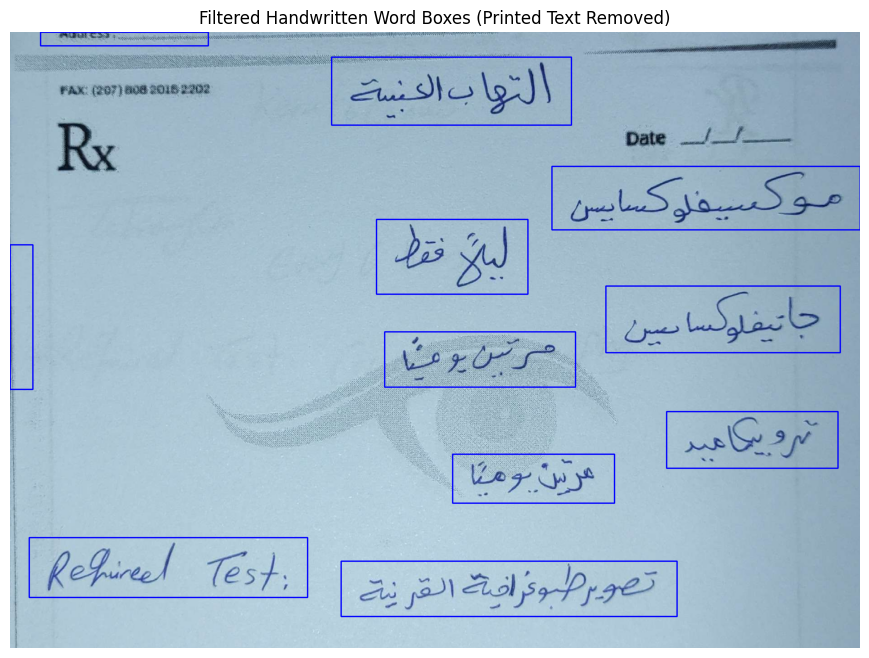

In [111]:
# Extract final handwritten-like boxes by filtering out printed text
# We'll use a heuristic: printed text has sharp edges and high contrast, so we can analyze texture and stroke density

handwritten_boxes = []

for (x, y, w, h) in final_boxes:
    roi = gray[y:y+h, x:x+w]
    
    # Resize to normalize size
    resized = cv2.resize(roi, (100, 40))
    
    # Calculate standard deviation and edges as features
    std_dev = np.std(resized)
    edges = cv2.Canny(resized, 100, 200)
    edge_density = np.sum(edges) / (100 * 40)

    # Handwritten regions tend to have lower edge density and moderate variation
    if 20 < std_dev < 30 and edge_density > 0.8:
        handwritten_boxes.append((x, y, w, h))

# Visualize filtered handwritten text boxes
filtered_img = img.copy()
for (x, y, w, h) in handwritten_boxes:
    cv2.rectangle(filtered_img, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(filtered_img, cv2.COLOR_BGR2RGB))
plt.title("Filtered Handwritten Word Boxes (Printed Text Removed)")
plt.axis("off")
plt.show()


In [83]:
import cv2
import numpy as np
from PIL import Image, ImageEnhance
import os

class ImagePreprocessor:
    def __init__(self, contrast_factor=1.5):
        self.contrast_factor = contrast_factor

    def enhance_contrast(self, image):
        enhancer = ImageEnhance.Contrast(image)
        return enhancer.enhance(self.contrast_factor)

    def denoise(self, image):
        img_array = np.array(image)
        denoised = cv2.fastNlMeansDenoisingColored(img_array, None, 10, 10, 7, 21)
        return Image.fromarray(denoised)

    def remove_background(self, image):
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        binary = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV, 11, 2
        )
        kernel = np.ones((2, 2), np.uint8)
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
        result = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(result)

    def process(self, image, save_path=None):
        image = self.enhance_contrast(image)
        image = self.denoise(image)
        image = self.remove_background(image)
        if save_path:
            image.save(save_path)
        return image



In [58]:

# --- Helper Functions (add your actual implementations here) ---
def thresholding(image, threshold_val, typee='Binary', param1=0, param2=0):
    return cv2.threshold(image, threshold_val, 255, cv2.THRESH_BINARY)[1]

def directionalHistogram(image, direction='H'):
    if direction == 'H':
        return np.sum(image == 0, axis=1)
    else:
        return np.sum(image == 0, axis=0)

def smoothHist(hist, window_size):
    return np.convolve(hist, np.ones(window_size)/window_size, mode='same')

def peakinterp(factor, hist, padding):
    # Dummy function (replace with real one)
    return np.array([100, 200]), hist, np.arange(len(hist)), np.arange(len(hist))

def findGradSignChange(hist_interp, x_vals, orig_vals):
    return np.sign(np.gradient(hist_interp))

def rle(arr):
    # Dummy run-length encoding
    from itertools import groupby
    values = [k for k, g in groupby(arr)]
    runlengths = [len(list(g)) for k, g in groupby(arr)]
    startpositions = np.cumsum([0] + runlengths[:-1])
    return runlengths, startpositions, values

def cutPositions(rl, sp, v, t, f):
    return np.array([50, 150, 250]), v

def optimalThreshold(cutpos, rl, sp, v, hist, peaks, a, b):
    return cutpos, hist

def cropImageToLines(cut_positions, image):
    lines = []
    for i in range(len(cut_positions)-1):
        lines.append(image[cut_positions[i]:cut_positions[i+1], :])
    return lines


# --- Main Pipeline ---


In [84]:
import matplotlib.pyplot as plt

def process_and_segment_image(image, output_dir_lines):

    # Step 1: Preprocess
    preprocessor = ImagePreprocessor()
    processed = preprocessor.process(image)

    # Convert for OpenCV usage
    processed_cv = np.array(processed.convert("RGB"))[..., ::-1]  # PIL to BGR
    gray = cv2.cvtColor(processed_cv, cv2.COLOR_BGR2GRAY)

    # Show original vs processed
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Processed Image")
    plt.imshow(processed, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Grayscale")
    plt.imshow(gray, cmap='gray')
    plt.axis('off')
    plt.show()

    # Step 2: Thresholding
    thresh = thresholding(gray, 240, typee='Binary', param1=0, param2=0)

    plt.figure(figsize=(6, 4))
    plt.title("Thresholded Image")
    plt.imshow(thresh, cmap='gray')
    plt.axis('off')
    plt.show()

    # Step 3: Horizontal histogram
    hist_horizontal = directionalHistogram(thresh)
    hist_horizontal_smooth = smoothHist(hist_horizontal, 17)

    # Show histograms
    plt.figure(figsize=(10, 4))
    plt.plot(hist_horizontal, label="Original Histogram", alpha=0.6)
    plt.plot(hist_horizontal_smooth, label="Smoothed Histogram", linewidth=2)
    plt.title("Horizontal Intensity Histogram")
    plt.xlabel("Row Index")
    plt.ylabel("Sum of White Pixels")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Step 4: Get cut positions
    peaks, smooth_interp, resampled_pixel_space, Original_pixel_space = peakinterp(100, hist_horizontal_smooth, 8)
    grad_sign_change = findGradSignChange(smooth_interp, resampled_pixel_space, Original_pixel_space)
    runlengths, startpositions, values = rle(grad_sign_change)
    cutpos, _ = cutPositions(runlengths, startpositions, values, 50, 100)
    cutpos, _ = optimalThreshold(cutpos, runlengths, startpositions, values, smooth_interp, peaks, 50, 100)

    # Visualize cut positions on histogram
    plt.figure(figsize=(10, 4))
    plt.plot(smooth_interp, label="Interpolated Smooth Histogram")
    for cp in cutpos:
        plt.axvline(x=cp, color='red', linestyle='--')
    plt.title("Cut Positions on Histogram")
    plt.xlabel("Pixel Index (Resampled)")
    plt.ylabel("Smoothed Intensity")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Step 5: Crop and save lines
    lines = cropImageToLines(cutpos.astype(int), thresh)

    plt.figure(figsize=(12, len(lines) * 2))
    for i, line in enumerate(lines):
        plt.subplot(len(lines), 1, i+1)
        plt.imshow(line, cmap='gray')
        plt.axis('off')
        plt.title(f"Line {i}")
        # Save to output directory
        cv2.imwrite(os.path.join(output_dir_lines, f"test_line_{i}.png"), line)
    plt.tight_layout()
    plt.show()


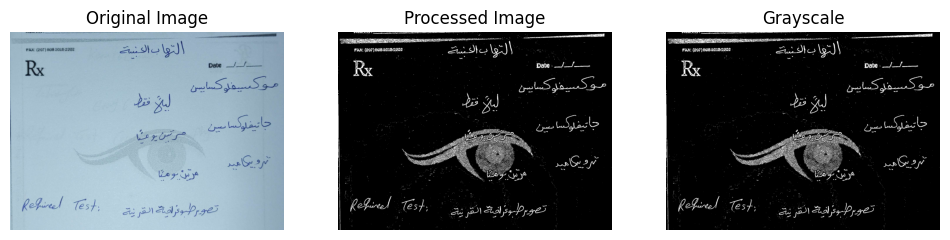

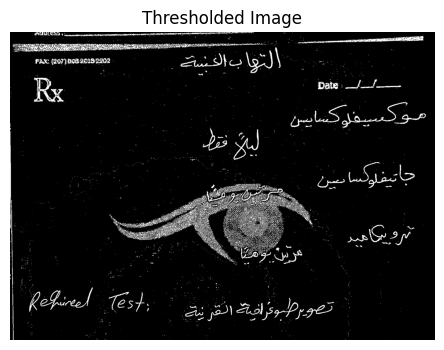

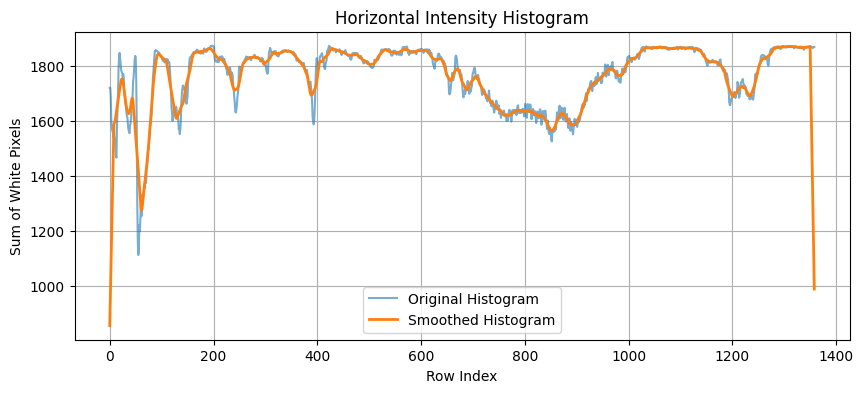

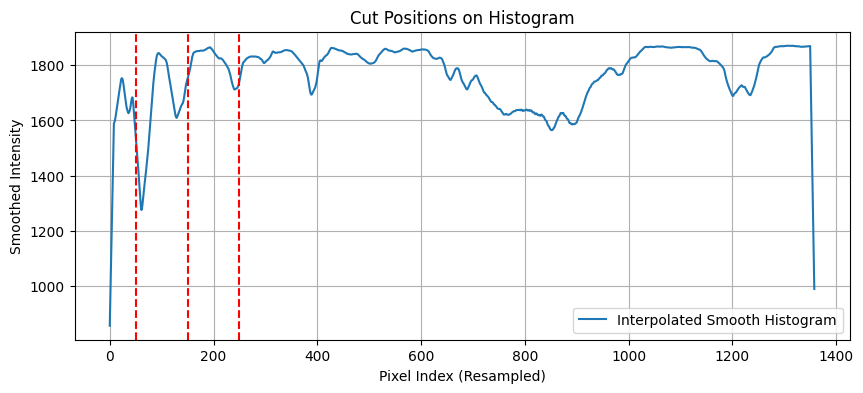

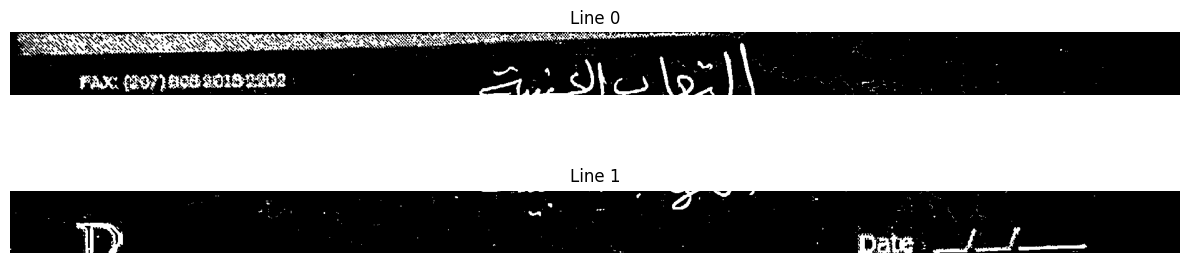

In [93]:
image = extracted_handwriting.get_cropped_image()
output_dir = "annotations deeb"
image_pil = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

process_and_segment_image(image_pil, output_dir)


In [ ]:
import os
import cv2
import numpy as np
from google.colab import files

# ======================
# Helpers
# ======================
def directionalHistogram(img, direction='H'):
    (w, h) = img.shape
    sum = []
    if direction == 'H':
        for j in range(w):
            sum.append(np.sum(img[j, :] == 255))
    else:
        for j in range(h):
            sum.append(np.sum(img[:, j] == 255))
    return sum

def cropImage(img, y_start, y_end):
    return img[y_start:y_end, :]

def cropLineToWords(viable_sequences, image):
    (w, h) = image.shape
    words = []
    for i in range(len(viable_sequences)):
        if i > 0 and i < len(viable_sequences):
            words.append(image[:, viable_sequences[i - 1]:viable_sequences[i]])
        elif i == len(viable_sequences) - 1:
            words.append(image[:, viable_sequences[i]:])
    return words

def removeSpaces(words):
    return [word for word in words if np.sum(word[:, :] > 0)]

# ======================
# Create Directories
# ======================
os.makedirs("/content/files_segmented", exist_ok=True)
os.makedirs("/content/words", exist_ok=True)

# ======================
# Read Main Image
# ======================
img = cv2.imread('/content/line_word.tif', 0)
_, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
(w, h) = img.shape

# ======================
# Line Segmentation
# ======================
hist = directionalHistogram(img, direction='H')
zero_sites = np.where(np.asarray(hist) == 0)[0]

sequences = []
sequence_start = 0
for i in range(1, len(zero_sites)):
    last_zero = zero_sites[i - 1]
    current_zero = zero_sites[i]
    if current_zero != last_zero + 1:
        sequence_end = last_zero
        sequences.append([sequence_start, sequence_end])
        sequence_start = current_zero
    if current_zero == last_zero + 1 and i == len(zero_sites) - 1:
        sequence_end = current_zero
        sequences.append([sequence_start, sequence_end])

sequence_lengths = [seq[1] - seq[0] + 1 for seq in sequences]
average_sequence_length = np.sum(sequence_lengths[1:-1]) / (len(sequence_lengths) - 2)
overlap_factor = 0.75 * average_sequence_length

viable_sequences = []
for i in range(len(sequences)):
    if sequence_lengths[i] >= average_sequence_length - overlap_factor:
        viable_sequences.append(sequences[i][0])
        viable_sequences.append(sequences[i][1])

if viable_sequences[0] != 0:
    viable_sequences = [0] + viable_sequences
viable_sequences.append(w)

# ======================
# For each line: extract line → segment words
# ======================
line_counter = 0
for i in range(0, len(viable_sequences) - 1, 2):
    y_start = viable_sequences[i]
    y_end = viable_sequences[i + 1]
    line_img = cropImage(img, y_start, y_end)
    line_filename = f"line_{line_counter}.tif"
    line_path = f"/content/files_segmented/{line_filename}"
    cv2.imwrite(line_path, line_img)
    
    # ========== Word Segmentation for each line ==========
    hist_vertical = directionalHistogram(line_img, direction='V')
    zero_sites = np.where(np.asarray(hist_vertical) == 0)[0]

    word_sequences = []
    sequence_start = 0
    for j in range(1, len(zero_sites)):
        last_zero = zero_sites[j - 1]
        current_zero = zero_sites[j]
        if current_zero != last_zero + 1:
            sequence_end = last_zero
            word_sequences.append([sequence_start, sequence_end])
            sequence_start = current_zero
        if current_zero == last_zero + 1 and j == len(zero_sites) - 1:
            sequence_end = current_zero
            word_sequences.append([sequence_start, sequence_end])

    word_lengths = [s[1] - s[0] + 1 for s in word_sequences]
    if len(word_lengths) <= 2:
        continue

    avg_len = np.sum(word_lengths[1:-1]) / (len(word_lengths) - 2)
    overlap_factor = 0.75 * avg_len

    viable_word_seqs_unrolled = []
    for s, l in zip(word_sequences, word_lengths):
        if l >= avg_len - overlap_factor:
            viable_word_seqs_unrolled.extend(s)

    if viable_word_seqs_unrolled[0] != 0:
        viable_word_seqs_unrolled = [0] + viable_word_seqs_unrolled
    viable_word_seqs_unrolled.append(-1)

    words = cropLineToWords(viable_word_seqs_unrolled, line_img)
    words = removeSpaces(words)

    # Save word images
    for k, word_img in enumerate(words):
        word_filename = f"/content/words/line{line_counter}_word{k+1}.tif"
        cv2.imwrite(word_filename, word_img)
        with open(word_filename.replace('.tif', '.txt'), 'w') as f:
            f.write('')

    line_counter += 1

# ======================
# Zip and Download
# ======================
!zip -r /content/words.zip /content/words
files.download("/content/words.zip")
